# PIECEWISE PREDICTIONS

This notebook explores the effect of oscillating species on the accuracy of a linear approximation. The conclusion is that the effect is minimal.

In [1]:
import matplotlib.pyplot as plt  # type: ignore
import numpy as np  # type: ignore
import os
import pandas as pd  # type: ignore
from src.timecourse_iterator import TimecourseIterator # type: ignore
from typing import Optional, cast, List, Union

import src.constants as cn
from src.score import Score
from src.system_discovery import SystemDiscovery  # type: ignore
from src.piecewise_system_discovery import PiecewiseSystemDiscovery
from src.model import Model
from src.timecourse import Timecourse
from src.system_discovery_changepoint_detector import SystemDiscoveryChangepointDetector

# Initializations

In [ ]:
# Non-oscillating species timecourses
path = os.path.join(cn.DATA_DIR, f"find_oscillating_models.csv")
NONOSCILLATION_DF = pd.read_csv(path)
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_FREQUENCIES] == "[]"]
NONOSCILLATION_DF = NONOSCILLATION_DF [NONOSCILLATION_DF[cn.COL_SPECIES_NAME] != cn.COL_AGGREGATION_TYPE_MODEL]
NONOSCILLATION_DF["key"] = [m + "_" + str(s) for m, s in zip(NONOSCILLATION_DF[cn.COL_SYSTEM_ID], NONOSCILLATION_DF[cn.COL_SPECIES_NAME])]
NONOSCILLATION_DF

# Individual models

In [ ]:
#for model_num in [45, 548, 551, 1045]:
#for model_num in [980, 1045]:
for model_num in [1045]:
    model = Model.makeBiomodel(model_num=model_num)
    timecourse = Timecourse(model, num_point =1000)
    df = timecourse.timecourse_df
    try:
        psd = PiecewiseSystemDiscovery(df, max_changepoint=10, min_segment_length=30,
                                        max_fractional_reduction=0.01, model_name=str(model_num))
        psd.fit()
        result = psd.plotPiecewise(legend=False, num_true_point=60)
    except Exception as e:
        print(f"Could not process {model_num}: {e}")

# Distribution of Number Species Across models

In [3]:
num_species_dct = {}
for item in TimecourseIterator():
    num_species_dct.update({item.model_name: len(item.timecourse.timecourse_df.columns)})
len(num_species_dct)

430

In [21]:
[m for m, s in num_species_dct.items() if s > 100]

['BIOMD0000000474', 'BIOMD0000000667']

In [ ]:
num_species_dct.values()

Text(0.5, 1.0, 'Number Species per Model')

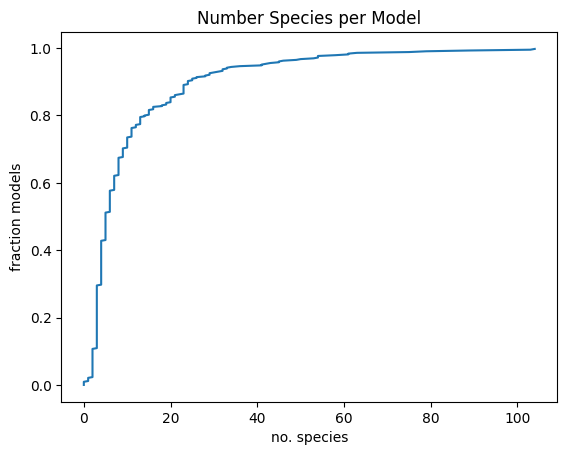

In [5]:
values = np.sort(list(num_species_dct.values()))
yv = np.array(range(len(values)))/len(values)
plt.plot(values, yv)
plt.xlabel("no. species")
plt.ylabel("fraction models")
plt.title("Number Species per Model")

Text(0.5, 1.0, 'CDF of Species by Model Size')

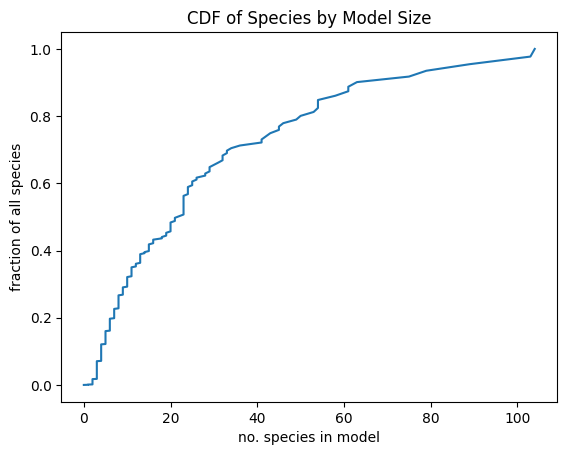

In [19]:
frac_species = np.cumsum(values)/np.sum(values)
_, ax = plt.subplots(1)
ax.plot(values, frac_species)
ax.set_xlabel("no. species in model")
ax.set_ylabel("fraction of all species")
ax.set_title("CDF of Species by Model Size")

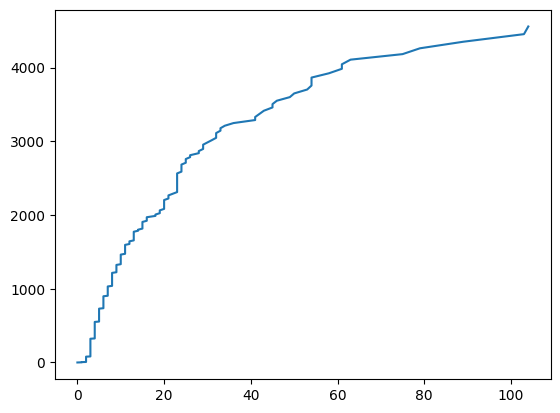

In [14]:
plt.plot(values, xv)

# CDFs

## All Models

In [ ]:
threshold = 0.001
#path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{threshold}.csv")
path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
DF = pd.read_csv(path)
DF

In [ ]:
def getColumn(df: pd.DataFrame, col: str = "a80",  is_species: bool = True, max_changepoint: int = 10,
        is_oscillation: bool = True) -> pd.Series:
    if is_species:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] != cn.COL_AGGREGATION_TYPE_MODEL]
    else:
        result_df = df[df[cn.COL_AGGREGATION_TYPE] == cn.COL_AGGREGATION_TYPE_MODEL]
    result_df = result_df[result_df[cn.COL_MAX_CHANGEPOINT] == max_changepoint]
    # Handle oscillations
    if not is_oscillation:
        pass
        
    return result_df[col]

# Tests
ser = getColumn(DF)
ser

In [ ]:
def plotCDF(coefficient_threshold: float = 0.001, max_changepoints=[0, 1, 5, 10, 15, 19], is_species: bool = True, col="p10",
        is_non_oscillating: Optional[bool] = None):
    # Construct the dataframe to process
    #path = os.path.join(cn.DATA_DIR, f"piecewise_predictions_{coefficient_threshold}.csv")
    path = os.path.join(cn.DATA_DIR, f"piecewise_predictions.csv")
    df = pd.read_csv(path)
    df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
    if is_non_oscillating is not None:
        df["key"] = NONOSCILLATION_DF[cn.COL_SYSTEM_ID] + "_" + NONOSCILLATION_DF[cn.COL_SPECIES_NAME]
        #
        sel = df["key"].isin(NONOSCILLATION_DF["key"].unique())
        if is_non_oscillating:
            df = df[sel]
        else:
            df = df[~sel]
    #
    dct = {c: getColumn(df, col=col, max_changepoint = c, is_species=is_species) for c in max_changepoints}
    for key, value in dct.items():
        Score.plotCDFArray(value)
    ax = plt.gca()
    ax.legend([str(c) for c in max_changepoints])
    ax.set_xlabel(col + " accuracy")
    qualifier1 = "species" if is_species else "models"
    model_sel = (df[cn.COL_AGGREGATION_TYPE] == "model") & (df[cn.COL_MAX_CHANGEPOINT] == 0)
    species_sel = (df[cn.COL_AGGREGATION_TYPE] != "model") & (df[cn.COL_MAX_CHANGEPOINT] == 0)
    species_length = np.sum(species_sel)
    model_length = np.sum(model_sel)
    if is_species:
        length = species_length
    else:
        length = model_length
    if is_non_oscillating is None:
        qualifier2 = "all"
    else:
        qualifier2 = "non-oscillating" if is_non_oscillating else "oscillating"
    ax.set_title(f"{qualifier2} ({length}) {qualifier1} CDF ({coefficient_threshold})")

plotCDF(coefficient_threshold=0.001, is_species=True)

In [ ]:
plotCDF(coefficient_threshold=0.001, is_species=False, col="p50")

**Observations**
1. Increasing the number of changepoints increases accuracy up to about 20 changepoints.
2. There is decreasing benefit of increasing the number of changepoints. For example, going from 0 to 1 changepoint, increases the fraction of p10 = 0.8  by 5%, but there is almost no increase the this fraction by increasing from 10 changepoints to 20 changepoints.
3. About 40% of the species trajectories have a p10 accuracy of 0 even if changepoints are considered.
4. The benefit of increasing changepoints diminishes with the p10 accuracy.
5. For 10 changepoints, approximately 50% of species have a p10 accuracy of 0.8 and 45% a p10 accuracy of 0.9.

In [ ]:
plotCDF(is_species = False, col="p50")

**Observations**
1. For 10 changepoints, approximately, 35% of models have a p10 accuracy of 0.8, and 30% of the models have a p10 accuracy of 0.9.
2. Accuracies for models are generally lower than those for species since a model combines many species and we are considering the tail of the distribution.
3. The other observations about species apply to models.

In [ ]:
len(DF["system_id"].unique())

## Oscillating vs. Non-Oscillating Models

In [ ]:
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=False)
plt.figure()
plotCDF(coefficient_threshold=0.001, is_species=True, is_non_oscillating=True)